# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал: лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

Обозначим

$$
\mathbf{x}=
\begin{pmatrix}
x_1\\
x_2\\
x_3
\end{pmatrix},
\qquad
\mathbf{p}=
\begin{pmatrix}
1\\
2\\
3
\end{pmatrix}.
$$
Т.е размерность x = 3

Тогда задача имеет вид

$$
\min_{\mathbf{x}\in\mathbb{R}^3}
\left\|\mathbf{x}-\mathbf{p}\right\|_2^2
$$
Но минимизировать расстояние и квадрат расстояния одно и то же. Поэтому удобнее взять

$$ f(x)=\|x-a\|_2^2. $$

То есть
$$
f(x) = (x_1 - 1)^2 + (x_2 - 2)^2 + (x_3 - 3)^2
$$	​



По условию точка должна принадлежать множеству

$$
\left\{
x\in\mathbb{R}^3 \;:\;
x_1+x_2+x_3=1,\;
x_1-x_3=0
\right\}.
$$

Переносим всё в левую часть:

$$
x_1+x_2+x_3-1=0,
$$

$$
x_1-x_3=0.
$$

Поэтому $g(x)$ — вектор из двух ограничений:

$$
g(x)=
\begin{pmatrix}
x_1+x_2+x_3-1 \\
x_1-x_3
\end{pmatrix}.
$$

При этом

$$
g:\mathbb{R}^3\to\mathbb{R}^2.
$$

Поскольку в данной задаче нет никаких неравенств, то $h(x)$ отсутствует

Класс задачи: QP (Quadratic Programming) с линейными ограничениями-равенствами

Задача выпуклая, потому что целевая функция

$$
f(x)=(x_1-1)^2+(x_2-2)^2+(x_3-3)^2
$$

имеет положительно определённую матрицу Гессе:

$$
\nabla^2 f(x)=2I \succ 0.
$$

Ограничения линейные, поэтому допустимое множество выпуклое. Следовательно, задача является выпуклой.

Дополнительно найдём ближайшую точку. Из ограничения

$$
x_1-x_3=0
$$



$$
x_3=x_1.
$$



$$
x_1+x_2+x_3=1
$$



$$
x_2=1-2x_1.
$$



$$
x_1=t.
$$


$$
x=
\begin{pmatrix}
t \\
1-2t \\
t
\end{pmatrix}.
$$


$$
f(t)=(t-1)^2+(1-2t-2)^2+(t-3)^2.
$$


$$
f(t)=6t^2-4t+11.
$$


$$
f'(t)=12t-4.
$$


$$
12t-4=0.
$$


$$
t=\frac{1}{3}.
$$


$$
x^*=
\begin{pmatrix}
\frac{1}{3} \\
\frac{1}{3} \\
\frac{1}{3}
\end{pmatrix}.
$$

In [2]:
x0_target = np.array([1.0, 2.0, 3.0])

A_eq = np.array([[1.0, 1.0, 1.0],
                 [1.0, 0.0, -1.0]])
b_eq = np.array([1.0, 0.0])

res = minimize(lambda x: np.sum((x - x0_target)**2), 
               x0=np.zeros(3), 
               constraints={'type': 'eq', 'fun': lambda x: A_eq @ x - b_eq})

print("Оптимальная точка x*:", np.round(res.x, 6))
print("Минимальное значение f(x*):", np.round(res.fun, 6))

Оптимальная точка x*: [0.333333 0.333333 0.333333]
Минимальное значение f(x*): 10.333333


**(б)**

Пусть

$$
x =
\begin{pmatrix}
x_1 \\
\vdots \\
x_n
\end{pmatrix}
\in \mathbb{R}^n,
$$

где $x_j$ — количество продукта $j$.


Стоимость покупки равна

$$
f(x)=c^T x=\sum_{j=1}^{n} c_j x_j.
$$

Для каждого питательного вещества $i$ требуется получить не менее $b_i$ единиц:

$$
\sum_{j=1}^{n} A_{ij}x_j \ge b_i,
\qquad i=1,\ldots,m.
$$

В матричном виде:

$$
Ax-b \ge 0.
$$

Также количество каждого продукта не может быть отрицательным:

$$
x \ge 0.
$$

Поэтому ограничения можно объединить в функцию

$$
h(x)=
\begin{pmatrix}
Ax-b \\
x
\end{pmatrix}
\ge 0.
$$

Ограничений-равенств нет, поэтому $g(x)$ отсутствует.

Итоговая задача в стандартной форме:

$$
\begin{aligned}
\min_{x\in\mathbb{R}^n}\quad & c^T x \\
\text{при}\quad & Ax-b \ge 0, \\
& x \ge 0.
\end{aligned}
$$

где

$$
A\in\mathbb{R}^{m\times n},
\qquad
c\in\mathbb{R}^n,
\qquad
b\in\mathbb{R}^m.
$$


Это LP (Linear Programming), поскольку целевая функция и все ограничения линейные.

Выпуклая задача, так как линейная целевая функция выпукла (и вогнута), а допустимое множество задано пересечением замкнутых полупространств (многогранник)

**(в)**

Пусть

$$
x=
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}
\in\mathbb{R}^2,
$$

где $x_1$ и $x_2$ - половины сторон прямоугольника.

Так как вершины прямоугольника лежат на единичной окружности,

$$
x_1^2+x_2^2=1.
$$

Площадь прямоугольника равна

$$
S=4x_1x_2.
$$

Максимизацию площади перепишем как минимизацию отрицательной площади:

$$
f(x)=-4x_1x_2.
$$

Ограничение-равенство:

$$
g(x)=x_1^2+x_2^2-1=0.
$$

Так как $x_1$ и $x_2$ являются длинами,

$$
x_1\geq0,\qquad x_2\geq0.
$$

Поэтому

$$
h(x)=
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}
\geq0.
$$


Итоговая стандартная форма:

$$
\begin{aligned}
\min_{x\in\mathbb{R}^2}\quad & -4x_1x_2\\
\text{при}\quad & x_1^2+x_2^2-1=0,\\
& x_1\geq0,\quad x_2\geq0.
\end{aligned}
$$

Это QCQP (Quadratically Constrained Quadratic Program), поскольку целевая функция квадратичная и имеется квадратичное ограничение.


Задача с ограничениями и невыпуклая: допустимое множество

$$
x_1^2+x_2^2=1,\qquad x_1,x_2\geq0
$$

представляет собой дугу окружности и не является выпуклым множеством.

**(г)**

Параметры модели:

$$
\mathbf{x}=
\begin{pmatrix}
x_1\\
x_2\\
x_3
\end{pmatrix}
\in\mathbb{R}^3.
$$

Целевая функция: 
$$
f(\mathbf{x})
=
\sum_{i=1}^{N}
\left(
x_1\sin(x_2t_i+x_3)-y_i
\right)^2.
$$

Ограничения отсутствуют:

$$
g(\mathbf{x})=\varnothing,
\qquad
h(\mathbf{x})=\varnothing.
$$

Это NLP без ограничений

Невыпуклая задача. Из-за тригонометрической зависимости по параметрам $x_2$ и $x_3$ целевая функция мультимодальна (имеет множество локальных минимумов и седловых точек)

**(д, бонус)**

Пусть

$$
x\in\mathbb{R}^n,
$$

и введём одну дополнительную переменную

$$
t\in\mathbb{R}.
$$

Исходная задача:

$$
\min_{x\in\mathbb{R}^n}\max_i |a_i^\top x-b_i|.
$$

Условие

$$
t\ge |a_i^\top x-b_i|
$$

эквивалентно двум линейным неравенствам:

$$
-t\le a_i^\top x-b_i\le t,
\qquad i=1,\ldots,m.
$$

То есть

$$
t-(a_i^\top x-b_i)\ge 0,
$$

$$
t+(a_i^\top x-b_i)\ge 0.
$$


Введём новую переменную

$$
z=
\begin{pmatrix}
x\\
t
\end{pmatrix}
\in\mathbb{R}^{n+1}.
$$

Тогда целевая функция:

$$
f(z)=t.
$$

Ограничений-равенств нет, поэтому $g(z)$ отсутствует.

Неравенства можно записать как

$$
h(z)=
\begin{pmatrix}
t-(a_1^\top x-b_1)\\
t+(a_1^\top x-b_1)\\
\vdots\\
t-(a_m^\top x-b_m)\\
t+(a_m^\top x-b_m)
\end{pmatrix}
\ge 0.
$$


Итоговая стандартная форма:

$$
\begin{aligned}
\min_{x,t}\quad & t\\
\text{при}\quad &
t-(a_i^\top x-b_i)\ge 0,\qquad i=1,\ldots,m,\\
&
t+(a_i^\top x-b_i)\ge 0,\qquad i=1,\ldots,m.
\end{aligned}
$$

Это LP (Linear Programming), так как целевая функция и все ограничения линейные.

Задача с ограничениями, гладкая и выпуклая, поскольку все функции в переформулированной задаче линейные, а допустимое множество задаётся линейными неравенствами.

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

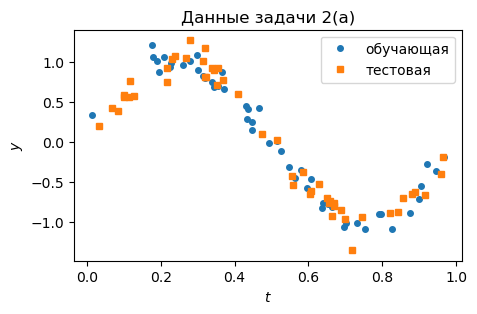

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

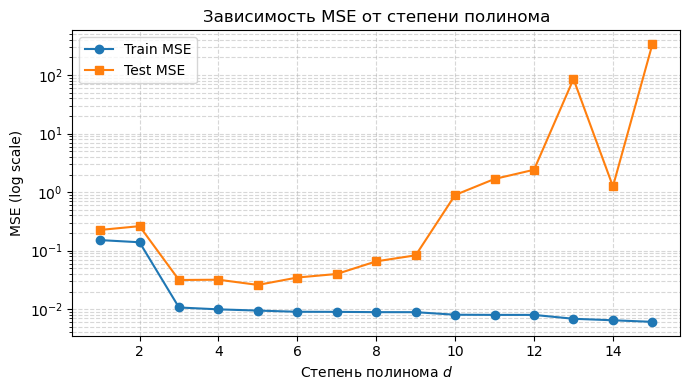

In [4]:
# ваш код
degrees = np.arange(1, 16)
mse_train = []
mse_test = []

for d in degrees:
    A_tr = np.vander(t_train, d + 1, increasing=True)
    A_te = np.vander(t_test, d + 1, increasing=True)
    
    w, _, _, _ = np.linalg.lstsq(A_tr, y_train, rcond=None)
    
    
    err_tr = np.mean((A_tr @ w - y_train) ** 2)
    err_te = np.mean((A_te @ w - y_test) ** 2)
    
    mse_train.append(err_tr)
    mse_test.append(err_te)

plt.figure(figsize=(7, 4))
plt.semilogy(degrees, mse_train, "o-", label="Train MSE")
plt.semilogy(degrees, mse_test, "s-", label="Test MSE")
plt.xlabel("Степень полинома $d$")
plt.ylabel("MSE (log scale)")
plt.title("Зависимость MSE от степени полинома")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Для каждой степени $d$ решается задача наименьших квадратов

$$
\min_{\mathbf{x}}
\left\|
A_d\mathbf{x}-\mathbf{y}
\right\|_2^2,
$$

где $A_d$ - матрица признаков для полинома степени $d$.

Ошибка на обучающей выборке при увеличении степени полинома не возрастает, поскольку

$$
\mathcal{P}_d\subseteq \mathcal{P}_{d+1},
$$

где $\mathcal{P}_d$ - множество полиномов степени не выше $d$.

То есть модель степени $d+1$ всегда может воспроизвести решение модели степени $d$, положив коэффициент при новом старшем члене равным нулю.

Поэтому

$$
\operatorname{MSE}_{\mathrm{train}}(d+1)
\le
\operatorname{MSE}_{\mathrm{train}}(d).
$$

На тестовой выборке ситуация другая. Сначала увеличение степени позволяет точнее приблизить зависимость

$$
y=\sin(2\pi t),
$$

и тестовая ошибка уменьшается. Однако при слишком большой степени модель начинает подстраиваться под шум обучающей выборки, то есть возникает **переобучение**.

Для полученных данных минимальная тестовая ошибка достигается при

$$
\boxed{d=5}.
$$

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
def solve_diet(b_vec):
    result = linprog(
        c,
        A_ub=-A,
        b_ub=-b_vec,
        bounds=(0, None),
        method="highs"
    )

    if not result.success:
        raise RuntimeError(result.message)

    x = result.x
    nutrient_slack = A @ x - b_vec

    active_nutrients = np.isclose(
        nutrient_slack, 0.0, atol=1e-9, rtol=0.0
    )
    active_nonneg = np.isclose(
        x, 0.0, atol=1e-9, rtol=0.0
    )

    return result, nutrient_slack, active_nutrients, active_nonneg



res1, slack1, active_A1, active_x1 = solve_diet(b)

print("Исходная задача")
print("x* =", res1.x)
print("Стоимость =", res1.fun)
print("Ax - b =", slack1)
print("Активные ограничения Ax >= b:", np.where(active_A1)[0] + 1)
print("Активные ограничения x >= 0:", np.where(active_x1)[0] + 1)


b_new = b.copy()
b_new[0] += 1

res2, slack2, active_A2, active_x2 = solve_diet(b_new)

print("\nПосле увеличения b1 на 1")
print("x* =", res2.x)
print("Стоимость =", res2.fun)
print("Ax - b_new =", slack2)
print("Активные ограничения Ax >= b_new:", np.where(active_A2)[0] + 1)
print("Активные ограничения x >= 0:", np.where(active_x2)[0] + 1)

print("\nИзменение решения =", res2.x - res1.x)
print("Изменение стоимости =", res2.fun - res1.fun)

Исходная задача
x* = [ 2.  4. -0.  0.]
Стоимость = 16.0
Ax - b = [0. 0. 0.]
Активные ограничения Ax >= b: [1 2 3]
Активные ограничения x >= 0: [3 4]

После увеличения b1 на 1
x* = [1.88888889 3.55555556 0.         0.66666667]
Стоимость = 17.11111111111111
Ax - b_new = [0. 0. 0.]
Активные ограничения Ax >= b_new: [1 2 3]
Активные ограничения x >= 0: [3]

Изменение решения = [-0.11111111 -0.44444444  0.          0.66666667]
Изменение стоимости = 1.1111111111111107


1. Исходная задача ($b = [10, 8, 12]^\top$):
   * Оптимальное решение: $x^* = (2, 4, 0, 0)^\top$ со стоимостью $16.0$.
   * Активные ограничения:
     * Все три требования по питательным веществам ($Ax \ge b$) активны: организм получает вещества в точности по норме, без избытка.
     * Ограничения неотрицательности ($x \ge 0$) активны для продуктов 3 и 4 (мы их вообще не покупаем, $x_3 = 0, x_4 = 0$).

2. После увеличения требования по первому веществу ($b_1 \to 11$):
   * Новое решение: $x^* \approx (1.89, 3.56, 0, 0.67)^\top$, новая стоимость составила $\approx 17.11$.
   * Активные ограничения:
     * По веществам по-прежнему активны все три ограничения.
     * По неотрицательности активно только ограничение для продукта 3 ($x_3 = 0$).

3. Сравнение:
   * Решение и стоимость: из-за возросших требований рацион стал дороже примерно на $1.11$ (вырос с $16.0$ до $17.11$). Мы стали покупать чуть меньше продуктов 1 и 2, но теперь пришлось докупить продукт 4 в объеме $\approx 0.67$.
   * Набор активных ограничений: набор изменился. Раньше мы не покупали продукты 3 и 4, а теперь покупаем продукт 4, поэтому ограничение $x_4 \ge 0$ перестало быть активным.